In [4]:
import os
import numpy as np
import librosa
import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
DATASET_PATH = "dataset"
CLASSES = ['clap', 'cough', 'knock', 'wave', 'whisle']

SEGMENT_DURATION = 0.5
OVERLAP = 0.25
N_MFCC = 40
SAMPLE_RATE = 22050

# We need a fixed time width for CNN input.
# 0.5s * 22050Hz / 512 (hop) approx = 22 frames.
# We will enforce this size.
FIXED_TIME_STEPS = 22


def extract_features_cnn(file_path, label):
    features = []
    labels = []

    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE)

        n_samples = int(SEGMENT_DURATION * sr)
        step = int((SEGMENT_DURATION - OVERLAP) * sr)

        if len(y) < n_samples:
            padding = n_samples - len(y)
            y = np.pad(y, (0, padding), mode='constant')

        for start in range(0, len(y) - n_samples + 1, step):
            segment = y[start:start + n_samples]

            # Extract MFCC (Shape: n_mfcc, time)
            mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=N_MFCC)

            # Transpose to (time, n_mfcc)
            mfcc = mfcc.T

            # Pad or Crop to FIXED_TIME_STEPS
            if mfcc.shape[0] < FIXED_TIME_STEPS:
                pad_width = FIXED_TIME_STEPS - mfcc.shape[0]
                mfcc = np.pad(mfcc, ((0, pad_width), (0, 0)), mode='constant')
            else:
                mfcc = mfcc[:FIXED_TIME_STEPS, :]

            features.append(mfcc)
            labels.append(label)

    except Exception as e:
        print(f"Error parsing {file_path}: {e}")

    return features, labels


# --- 1. Load Data ---
print("Loading dataset for CNN...")
X_data = []
y_data = []

for class_name in CLASSES:
    folder_path = os.path.join(DATASET_PATH, class_name)
    audio_files = glob.glob(os.path.join(folder_path, "*.wav"))
    print(f"Processing '{class_name}': found {len(audio_files)} files")

    for file_path in audio_files:
        feats, labs = extract_features_cnn(file_path, class_name)
        X_data.extend(feats)
        y_data.extend(labs)

X = np.array(X_data)
y = np.array(y_data)

print(f"Input Shape: {X.shape}")  # (Samples, 22, 40)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

# --- 2. Build CNN Model ---
input_shape = (FIXED_TIME_STEPS, N_MFCC)

model = Sequential([
    Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(len(CLASSES), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# --- 3. Train ---
print("\nTraining CNN...")
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# --- 4. Evaluate ---
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# --- 5. Export to TFLite ---
print("\nConverting to TFLite...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_filename = "audio_cnn_folder_model.tflite"
with open(tflite_filename, 'wb') as f:
    f.write(tflite_model)

print(f"Success! Model exported to '{tflite_filename}'")



Loading dataset for CNN...
Processing 'clap': found 3 files
Processing 'cough': found 3 files
Processing 'knock': found 3 files
Processing 'wave': found 3 files
Processing 'whisle': found 3 files
Input Shape: (105, 22, 40)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training CNN...
Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - accuracy: 0.1497 - loss: 29.9530 - val_accuracy: 0.2857 - val_loss: 11.4640
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2188 - loss: 28.2691 - val_accuracy: 0.3333 - val_loss: 6.1096
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2991 - loss: 18.8678 - val_accuracy: 0.3810 - val_loss: 7.4733
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4154 - loss: 14.8314 - val_accuracy: 0.4762 - val_loss: 7.2468
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3958 - loss: 7.7183 - val_accuracy: 0.5238 - val_loss: 6.7183
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5532 - loss: 5.8526 - val_accuracy: 0.7143 - val_loss: 6.4849
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5197 - loss: 6.1087 - val_accuracy: 0.6667 - val_loss: 6.2963
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6735 - loss: 5.3355 - val_accuracy: 0.6

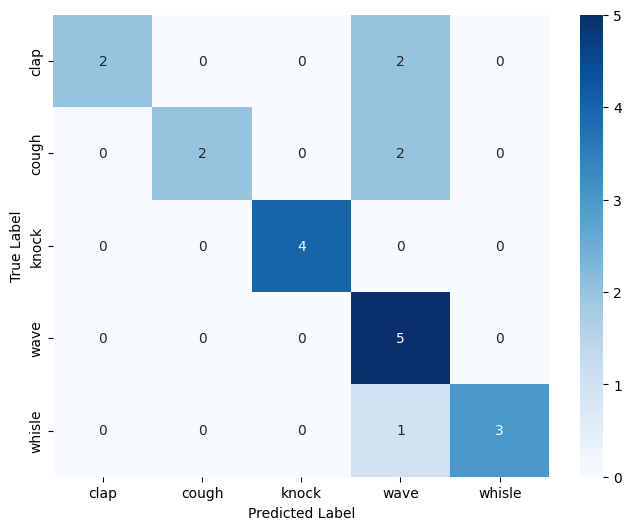

In [5]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

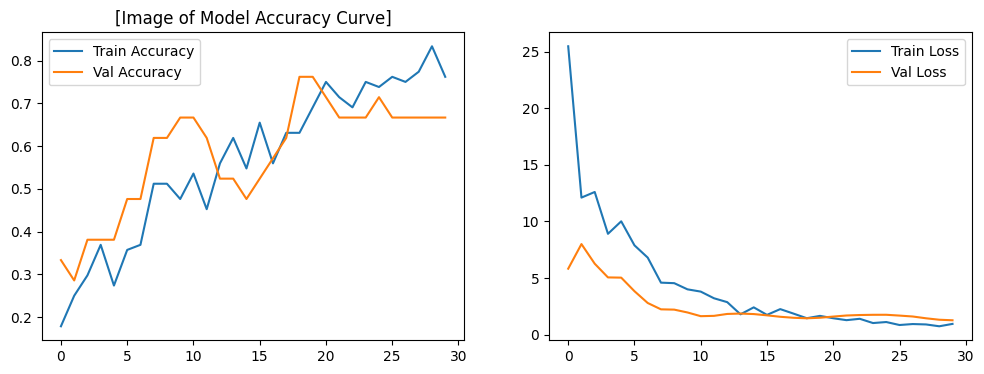

In [ ]:
# Loss and Accuracy Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('[Image of Model Accuracy Curve]')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('')
plt.legend()
plt.show()